In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

columns_train = [
    "age",
    "workclass",
    "finalWeight",
    "education",
    "educationNum",
    "maritalStatus",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capGain",
    "capLoss",
    "hoursPerWeek",
    "nativeCountry",
    "income",
]

columns_test = [
    "age",
    "workclass",
    "finalWeight",
    "education",
    "educationNum",
    "maritalStatus",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capGain",
    "capLoss",
    "hoursPerWeek",
    "nativeCountry",
]

df_train = pd.read_csv(
    "data.txt", header=None, names=columns_train, na_values="?", skipinitialspace=True
)

df_test = pd.read_csv(
    "test_empty.txt",
    header=None,
    names=columns_test,
    na_values="?",
    skipinitialspace=True,
)

for col in ["workclass", "occupation", "nativeCountry"]:
    mode_val = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(mode_val)
    df_test[col] = df_test[col].fillna(mode_val)

df_train = df_train.dropna()
df_test = df_test.dropna()

df_train["income"] = df_train["income"].map({"<=N": 0, ">N": 1})

X = df_train.drop("income", axis=1)
y = df_train["income"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_val.shape)

(26056, 14)
(6515, 14)


1. загрузил тренировочный и тестовые датасеты
2. Пропуски в "workclass", "occupation", "nativeCountry" обработал с помощью моды, остальные удалил
3. Закодировал целевую переменную,разделил на train/test(val)


In [84]:
target_mean = X_train.join(y_train).groupby("nativeCountry")["income"].mean()

X_train["nativeCountry"] = X_train["nativeCountry"].map(target_mean)
X_val["nativeCountry"] = X_val["nativeCountry"].map(target_mean)
df_test["nativeCountry"] = df_test["nativeCountry"].map(target_mean)

fill_val = target_mean.mean()
X_train["nativeCountry"] = X_train["nativeCountry"].fillna(fill_val)
X_val["nativeCountry"] = X_val["nativeCountry"].fillna(fill_val)
df_test["nativeCountry"] = df_test["nativeCountry"].fillna(fill_val)


categ_cols = [
    "workclass",
    "education",
    "maritalStatus",
    "occupation",
    "relationship",
    "race",
    "sex",
]

X_train = pd.get_dummies(X_train, columns=categ_cols)
X_val = pd.get_dummies(X_val, columns=categ_cols)
df_test = pd.get_dummies(df_test, columns=categ_cols)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
df_test = df_test.reindex(columns=X_train.columns, fill_value=0)
print(X_train.shape)
print(X_val.shape)
print(df_test.shape)

(26056, 67)
(6515, 67)
(16282, 67)


1. nativeCountry закодировал через target
2. остальные One-Hot Encoding
3. колонки выровнял через reindex


In [85]:
num_cols = [
    "age",
    "finalWeight",
    "educationNum",
    "capGain",
    "capLoss",
    "hoursPerWeek",
    "nativeCountry",
]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

print(X_train[num_cols].describe().round(2))

            age  finalWeight  educationNum   capGain   capLoss  hoursPerWeek  \
count  26056.00     26056.00      26056.00  26056.00  26056.00      26056.00   
mean       0.00         0.00         -0.00     -0.00      0.00         -0.00   
std        1.00         1.00          1.00      1.00      1.00          1.00   
min       -2.75        -2.21         -3.53     -0.15     -0.49         -0.02   
25%       -0.77        -0.68         -0.42     -0.15     -0.22         -0.02   
50%       -0.12        -0.11         -0.03     -0.15     -0.22         -0.02   
75%        0.69         0.45          0.75     -0.15     -0.22         -0.02   
max        3.77        12.32          2.30     13.39     10.60         57.06   

       nativeCountry  
count       26056.00  
mean           -0.00  
std             1.00  
min            -5.70  
25%             0.14  
50%             0.14  
75%             0.14  
max             5.19  


масштабировал числовые признаки


In [86]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)
y_prob_lr = lr.predict_proba(X_val)[:, 1]
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_prob_lr):.4f}")
print(classification_report(y_val, y_pred_lr, target_names=["<=N", ">N"]))
print()

Accuracy: 0.8528
ROC-AUC:  0.9058
              precision    recall  f1-score   support

         <=N       0.88      0.93      0.91      4954
          >N       0.74      0.60      0.66      1561

    accuracy                           0.85      6515
   macro avg       0.81      0.77      0.78      6515
weighted avg       0.85      0.85      0.85      6515




In [87]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_prob_rf):.4f}")
print(classification_report(y_val, y_pred_rf, target_names=["<=N", ">N"]))
print()

Accuracy: 0.8516
ROC-AUC:  0.8979
              precision    recall  f1-score   support

         <=N       0.89      0.92      0.90      4954
          >N       0.71      0.63      0.67      1561

    accuracy                           0.85      6515
   macro avg       0.80      0.78      0.79      6515
weighted avg       0.85      0.85      0.85      6515




In [88]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:, 1]
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_prob_xgb):.4f}")
print(classification_report(y_val, y_pred_xgb, target_names=["<=N", ">N"]))
print()

Accuracy: 0.8744
ROC-AUC:  0.9287
              precision    recall  f1-score   support

         <=N       0.90      0.94      0.92      4954
          >N       0.78      0.67      0.72      1561

    accuracy                           0.87      6515
   macro avg       0.84      0.80      0.82      6515
weighted avg       0.87      0.87      0.87      6515




обучил три модели с базовыми параметрами, исходя из выводов лучшим оказался
XGBoost, его и буду брать для дальнейшей работы


In [89]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print("Лучшие параметры:", xgb_search.best_params_)
print("Лучший ROC-AUC (cv):", round(xgb_search.best_score_, 4))
best_xgb = xgb_search.best_estimator_
y_pred_best = best_xgb.predict(X_val)
y_prob_best = best_xgb.predict_proba(X_val)[:, 1]

print(f"\nAccuracy: {accuracy_score(y_val, y_pred_best):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_prob_best):.4f}")
print(classification_report(y_val, y_pred_best, target_names=["<=N", ">N"]))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Лучший ROC-AUC (cv): 0.9235

Accuracy: 0.8748
ROC-AUC:  0.9295
              precision    recall  f1-score   support

         <=N       0.90      0.95      0.92      4954
          >N       0.79      0.65      0.71      1561

    accuracy                           0.87      6515
   macro avg       0.84      0.80      0.82      6515
weighted avg       0.87      0.87      0.87      6515



Подбираю гиперпараметры и вывожу лучшие из них
после подбора Accuracy=0.8748, ROC-AUC=0.9295 видим небольшое улучшение


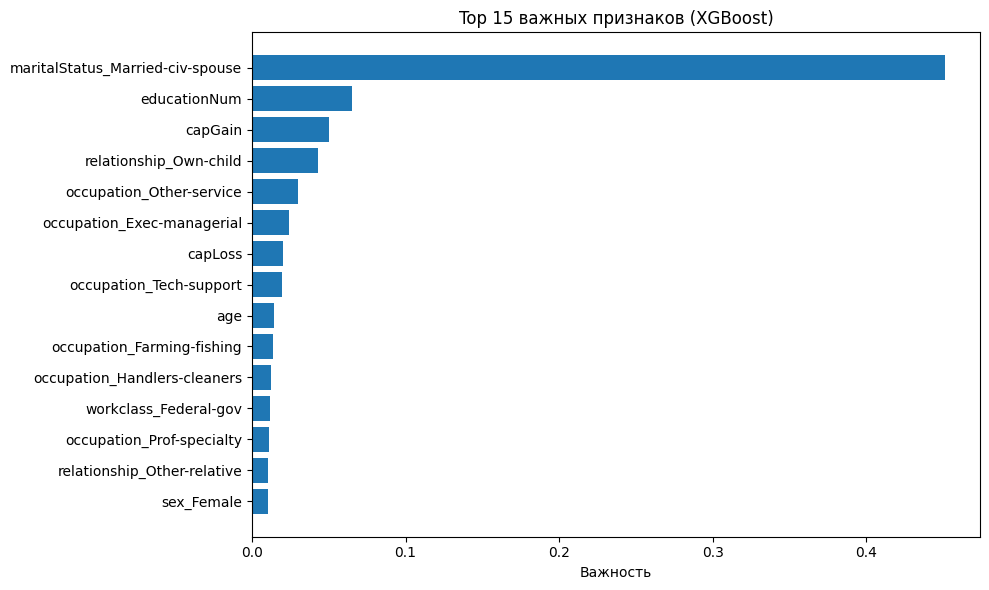

maritalStatus_Married-civ-spouse    0.451305
educationNum                        0.065164
capGain                             0.049975
relationship_Own-child              0.043130
occupation_Other-service            0.030109
occupation_Exec-managerial          0.024100
capLoss                             0.020260
occupation_Tech-support             0.019346
age                                 0.014598
occupation_Farming-fishing          0.013941
occupation_Handlers-cleaners        0.012439
workclass_Federal-gov               0.012066
occupation_Prof-specialty           0.010844
relationship_Other-relative         0.010730
sex_Female                          0.010543
dtype: float32


In [91]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Feature Importance
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(
    ascending=False
)[:15]

plt.figure(figsize=(10, 6))
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1])
plt.title("Top 15 важных признаков (XGBoost)")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

print(feat_imp)

вывел 15 важных признаков
Топ 3:

1. семейное положение
2. уровень образования
3. прирост капитала


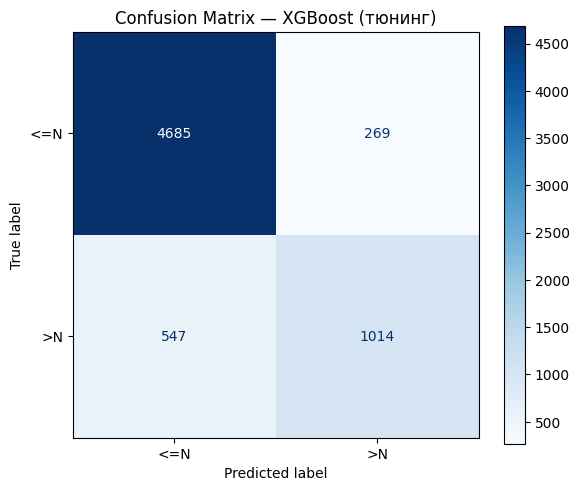

In [92]:
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=N", ">N"])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix — XGBoost (тюнинг)")
plt.tight_layout()
plt.show()

вывел матрицу ошибок
Модель хорошо распознает <=N, но хуже >N
Видим дисбаланс классов, дальше попробую это исправить введя scale_pos_weight=3


In [93]:
xgb_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss",
)
xgb_balanced.fit(X_train, y_train)
y_pred_bal = xgb_balanced.predict(X_val)
y_prob_bal = xgb_balanced.predict_proba(X_val)[:, 1]

print(f"Accuracy: {accuracy_score(y_val, y_pred_bal):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, y_prob_bal):.4f}")
print(classification_report(y_val, y_pred_bal, target_names=["<=N", ">N"]))

Accuracy: 0.8322
ROC-AUC:  0.9299
              precision    recall  f1-score   support

         <=N       0.95      0.82      0.88      4954
          >N       0.60      0.87      0.71      1561

    accuracy                           0.83      6515
   macro avg       0.78      0.84      0.80      6515
weighted avg       0.87      0.83      0.84      6515



> N вырос с 0.65 до 0.87, но общая точность снизилась.
> Поэтому выбираю для теста без балансировки


In [94]:
test_predictions = best_xgb.predict(df_test)
test_proba = best_xgb.predict_proba(df_test)[:, 1]

result = pd.DataFrame(
    {
        "predicted_label": pd.Series(test_predictions).map({0: "<=N", 1: ">N"}),
        "probability_>N": test_proba.round(4),
    }
)

print(result["predicted_label"].value_counts())
print(result.head(10))

result.to_csv("predictions.csv", index=False)
print("Предсказания сохранены в predictions.csv")

predicted_label
<=N    13197
>N      3085
Name: count, dtype: int64
  predicted_label  probability_>N
0             <=N          0.0028
1             <=N          0.1644
2             <=N          0.4253
3              >N          0.9951
4             <=N          0.0011
5             <=N          0.0191
6             <=N          0.0144
7              >N          0.8630
8             <=N          0.0062
9             <=N          0.1038
Предсказания сохранены в predictions.csv


Всего записей: 16 282

- Предсказано <=N: 13 197 (81%)
- Предсказано >N: 3 085 (19%)
- Результаты сохранены в `predictions.csv`
